In [347]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
%matplotlib inline 
sns.set(style="ticks")

In [348]:
#загрузка данных
wine = load_wine(as_frame=True)
data = wine.data
target = wine.target

In [349]:
data['target'] = target

In [350]:
#вывод датасета
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [351]:
#какие типы данных присутствуют
data.dtypes
# alcohol	алкоголь (содержание, % )
# malic_acid	яблочная кислота (г/л)
# ash	зола (содержание, г/л)
# alcalinity_of_ash	щелочность золы
# magnesium	магний (содержание, мг/л)
#total_phenols	общее содержание фенолов
#flavanoids	флавоноиды
#nonflavanoid_phenols	нефлавоноидные фенолы
#proanthocyanins	проантоцианины
#color_intensity	интенсивность цвета
#hue	оттенок (цветовой тон)
#od280/od315_of_diluted_wines	оптическая плотность (OD280/OD315) разбавленных вин
#proline	пролин (аминокислота, мг/л)
#target	целевая переменная (таргет) — сорт вина (0, 1 или 2)

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

In [352]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 178


In [354]:
# выведем статистические характеристики
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [355]:
#проверка на наличие пропусков
data.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [405]:
#масштабирование данных на основе Z-оценки
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [406]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [407]:
#разделение на обучающую и тестовые выборки
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine.data, wine.target, test_size=0.3, random_state=1)
print(f"Обучающая выборка: {wine_X_train.shape[0]} объектов {wine_X_train.shape[0]/178 * 100:.1f} %")
print(f"Тестовая выборка: {wine_X_test.shape[0]} объектов {wine_X_test.shape[0]/178 * 100:.1f} %")

Обучающая выборка: 124 объектов 69.7 %
Тестовая выборка: 54 объектов 30.3 %


In [408]:
np.unique(wine_y_train)
np.unique(wine_y_test)

array([0, 1, 2])

In [409]:
print("Распределение классов в обучающей выборке:")
for i, name in enumerate(wine.target_names):
    count = np.sum(wine_y_train == i)
    print(f"  {name}: {count} ({count/len(wine_y_train)*100:.1f}%)")

print("Распределение классов в тестовой выборке:")
for i, name in enumerate(wine.target_names):
    count = np.sum(wine_y_test == i)
    print(f"  {name}: {count} ({count/len(wine_y_test)*100:.1f}%)")

Распределение классов в обучающей выборке:
  class_0: 36 (29.0%)
  class_1: 52 (41.9%)
  class_2: 36 (29.0%)
Распределение классов в тестовой выборке:
  class_0: 23 (42.6%)
  class_1: 19 (35.2%)
  class_2: 12 (22.2%)


In [410]:
# 20 ближайших соседей
cl1_1 = KNeighborsClassifier(n_neighbors=20)
cl1_1.fit(wine_X_train, wine_y_train)
# предсказание
target1_0 = cl1_1.predict(wine_X_train)
target1_1 = cl1_1.predict(wine_X_test)
# оценка качества
print(accuracy_score(wine_y_train, target1_0), accuracy_score(wine_y_test, target1_1))
len(target1_1), target1_1

0.7258064516129032 0.7407407407407407


(54,
 array([2, 1, 2, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
        2, 0, 2, 2, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 0, 0, 1, 1, 2,
        0, 0, 2, 0, 0, 0, 1, 2, 2, 0]))

In [411]:
# 5 ближайших соседей
cl1_2 = KNeighborsClassifier(n_neighbors=5)
cl1_2.fit(wine_X_train, wine_y_train)
target1_01 = cl1_2.predict(wine_X_train)
target1_2 = cl1_2.predict(wine_X_test)
print(accuracy_score(wine_y_train, target1_01), accuracy_score(wine_y_test, target1_2))
len(target1_2), target1_2

0.8145161290322581 0.7037037037037037


(54,
 array([1, 1, 2, 2, 0, 1, 2, 0, 2, 1, 0, 2, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1,
        2, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 2, 1, 1, 2, 1, 0, 0, 1, 2, 0,
        0, 0, 0, 0, 0, 0, 1, 2, 2, 0]))

In [412]:
# 1 ближайший сосед
cl1_3 = KNeighborsClassifier(n_neighbors=1)
cl1_3.fit(wine_X_train, wine_y_train)
target1_02 = cl1_3.predict(wine_X_train)
target1_3 = cl1_3.predict(wine_X_test)
print(accuracy_score(wine_y_train, target1_02), accuracy_score(wine_y_test, target1_3))
len(target1_3), target1_3

1.0 0.7407407407407407


(54,
 array([2, 1, 2, 2, 0, 1, 2, 0, 1, 1, 0, 1, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1,
        2, 0, 0, 1, 0, 0, 0, 2, 1, 2, 1, 0, 1, 1, 1, 2, 1, 0, 0, 1, 1, 0,
        0, 0, 1, 0, 0, 0, 1, 1, 2, 0]))

In [413]:
def accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса, 
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame 
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют 
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values, 
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [414]:
print_accuracy_score_for_classes(wine_y_test, target1_1)

Метка 	 Accuracy
0 	 0.8260869565217391
1 	 0.7894736842105263
2 	 0.5


In [415]:
print_accuracy_score_for_classes(wine_y_test, target1_2)

Метка 	 Accuracy
0 	 0.9130434782608695
1 	 0.631578947368421
2 	 0.4166666666666667


In [416]:
print_accuracy_score_for_classes(wine_y_test, target1_3)

Метка 	 Accuracy
0 	 0.9130434782608695
1 	 0.7368421052631579
2 	 0.4166666666666667


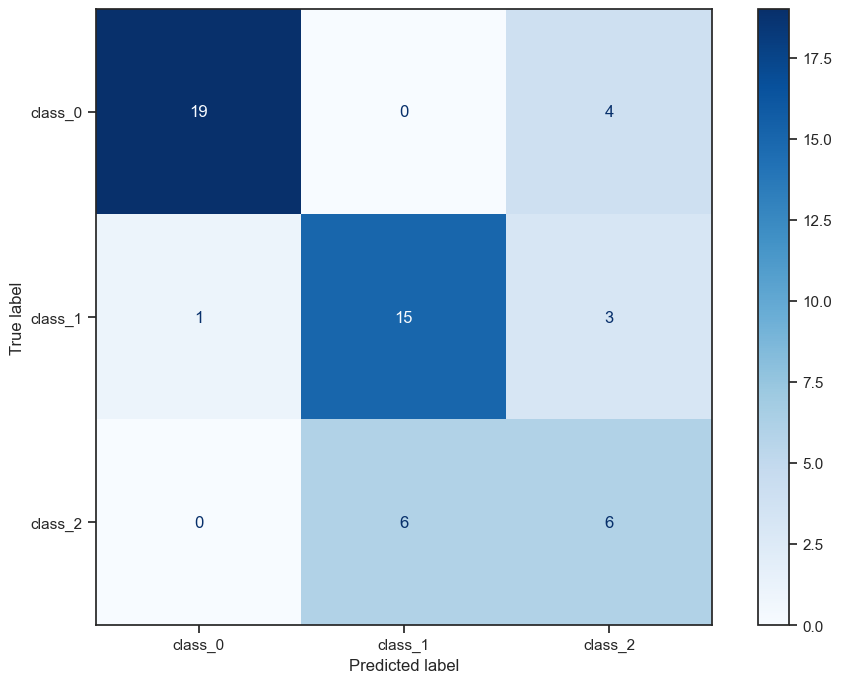

In [417]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(cl1_1, wine_X_test, wine_y_test, 
                      display_labels=wine.target_names, cmap=plt.cm.Blues)

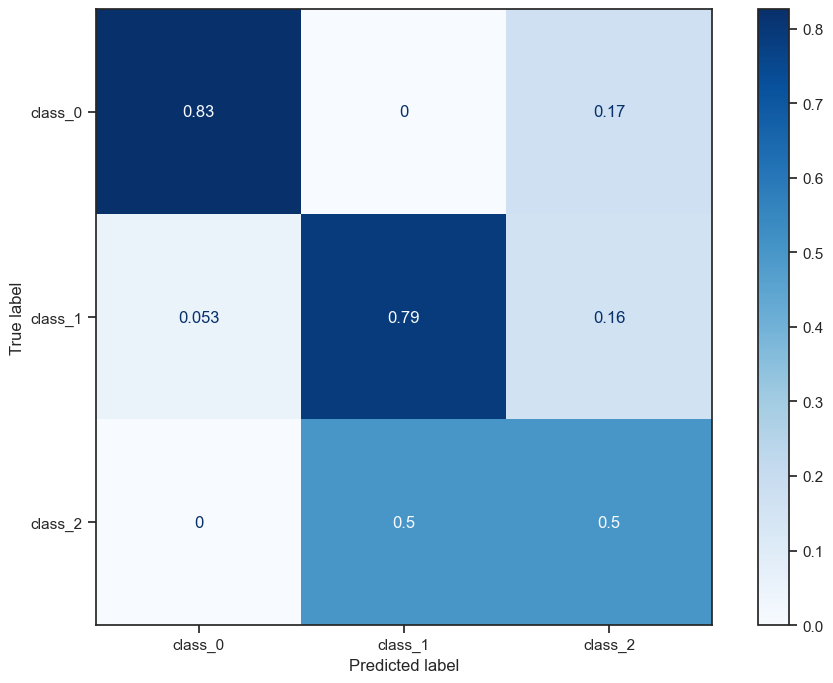

In [418]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(cl1_1, wine_X_test, wine_y_test, 
                      display_labels=wine.target_names, cmap=plt.cm.Blues, normalize='true')

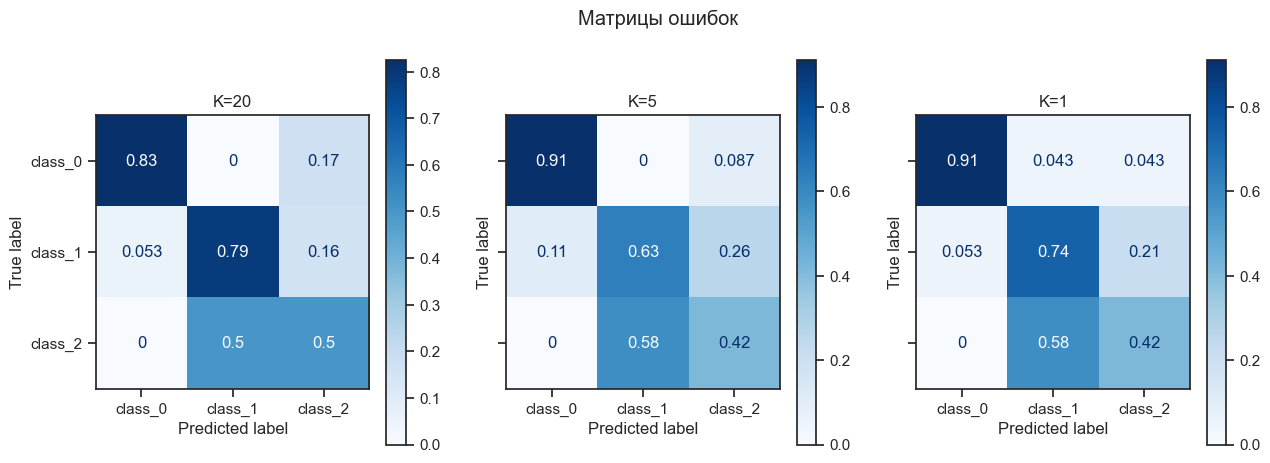

In [419]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))

ConfusionMatrixDisplay.from_estimator(cl1_1, wine_X_test, wine_y_test, 
                      display_labels=wine.target_names, 
                      cmap=plt.cm.Blues, normalize='true', ax=ax[0])

ConfusionMatrixDisplay.from_estimator(cl1_2, wine_X_test, wine_y_test, 
                      display_labels=wine.target_names, 
                      cmap=plt.cm.Blues, normalize='true', ax=ax[1])

ConfusionMatrixDisplay.from_estimator(cl1_3, wine_X_test, wine_y_test, 
                      display_labels=wine.target_names, 
                      cmap=plt.cm.Blues, normalize='true', ax=ax[2])

fig.suptitle('Матрицы ошибок')
ax[0].title.set_text('K=20')
ax[1].title.set_text('K=5')
ax[2].title.set_text('K=1')

In [420]:
#Precision, recall и F-мера

In [421]:
# Параметры TP, TN, FP, FN считаются как сумма по всем классам
# Параметр average (уровень детализации метрик)
(precision_score(wine_y_test, target1_1, average='micro'), recall_score(wine_y_test, target1_1, average='micro'))

(0.7407407407407407, 0.7407407407407407)

In [422]:
# Параметры TP, TN, FP, FN считаются отдельно для каждого класса 
# и берется среднее значение, дисбаланс классов не учитывается.
(precision_score(wine_y_test, target1_1, average='macro'), recall_score(wine_y_test, target1_1, average='macro'))

(0.7086080586080586, 0.7051868802440885)

In [423]:
# Параметры TP, TN, FP, FN считаются отдельно для каждого класса 
# и берется средневзвешенное значение, дисбаланс классов учитывается 
# в виде веса классов (вес - количество истинных значений каждого класса).
(precision_score(wine_y_test, target1_1, average='weighted'), recall_score(wine_y_test, target1_1, average='weighted'))

(0.7585164835164835, 0.7407407407407407)

In [424]:
# Для того, чтобы объединить precision и recall в единую метрику используется  Fβ 
# -мера, которая вычисляется как среднее гармоническое от precision и recall
f1_score(wine_y_test, target1_1, average='micro')

0.7407407407407407

In [425]:
f1_score(wine_y_test, target1_1, average='macro')

0.7045736434108528

In [426]:
f1_score(wine_y_test, target1_1, average='weighted')

0.7469552110249784

In [427]:
# Функция classification_report позволяет выводить значения точности, полноты и F-меры для всех классов выбор
from sklearn.metrics import classification_report
classification_report(wine_y_test, target1_1, 
                      target_names=wine.target_names, output_dict=True)

{np.str_('class_0'): {'precision': 0.95,
  'recall': 0.8260869565217391,
  'f1-score': 0.8837209302325582,
  'support': 23.0},
 np.str_('class_1'): {'precision': 0.7142857142857143,
  'recall': 0.7894736842105263,
  'f1-score': 0.75,
  'support': 19.0},
 np.str_('class_2'): {'precision': 0.46153846153846156,
  'recall': 0.5,
  'f1-score': 0.48,
  'support': 12.0},
 'accuracy': 0.7407407407407407,
 'macro avg': {'precision': 0.7086080586080586,
  'recall': 0.7051868802440885,
  'f1-score': 0.7045736434108528,
  'support': 54.0},
 'weighted avg': {'precision': 0.7585164835164835,
  'recall': 0.7407407407407407,
  'f1-score': 0.7469552110249784,
  'support': 54.0}}

In [428]:
# кросс-валидация
#В отличие от функции cross_val_score, функция cross_validate позволяет использовать для оценки несколько метрик
# и возращает более детальную информацию.
scoring = {'precision': 'precision_weighted', 
           'recall': 'recall_weighted',
           'f1': 'f1_weighted'}

In [429]:
scores = cross_validate(KNeighborsClassifier(n_neighbors=5), 
                        wine.data, wine.target, scoring=scoring, 
                        cv=3, return_train_score=True)
scores

{'fit_time': array([0.00113988, 0.00082517, 0.00068879]),
 'score_time': array([0.00498295, 0.00443482, 0.00379014]),
 'test_precision': array([0.60288799, 0.62569982, 0.75448133]),
 'train_precision': array([0.82841208, 0.81069416, 0.75911216]),
 'test_recall': array([0.61666667, 0.61016949, 0.76271186]),
 'train_recall': array([0.83050847, 0.80672269, 0.76470588]),
 'test_f1': array([0.60184394, 0.61521778, 0.75627992]),
 'train_f1': array([0.82918272, 0.80812733, 0.7588654 ])}

In [430]:
from sklearn.model_selection import KFold, RepeatedKFold, LeaveOneOut, LeavePOut, ShuffleSplit, StratifiedKFold
# cтратегия K-fold
X = range(12)
kf = KFold(n_splits=3)
for train, test in kf.split(X):
    print("%s %s" % (train, test))

[ 4  5  6  7  8  9 10 11] [0 1 2 3]
[ 0  1  2  3  8  9 10 11] [4 5 6 7]
[0 1 2 3 4 5 6 7] [ 8  9 10 11]


In [431]:
# Далее итератор может быть использован в функциях cross_val_score и cross_validate
kf = KFold(n_splits=5)
scores = cross_validate(KNeighborsClassifier(n_neighbors=5), 
                        wine.data, wine.target, scoring=scoring, 
                        cv=kf, return_train_score=True)
scores

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

{'fit_time': array([0.00098109, 0.0008769 , 0.00092793, 0.00073171, 0.00080395]),
 'score_time': array([0.00444698, 0.00602102, 0.00455713, 0.0033133 , 0.00406313]),
 'test_precision': array([1.        , 0.97222222, 1.        , 0.81002506, 1.        ]),
 'train_precision': array([0.77460706, 0.81102616, 0.81993242, 0.76249247, 0.88671918]),
 'test_recall': array([0.86111111, 0.83333333, 0.55555556, 0.77142857, 0.02857143]),
 'train_recall': array([0.77464789, 0.8028169 , 0.81690141, 0.76223776, 0.88811189]),
 'test_f1': array([0.92537313, 0.88624339, 0.71428571, 0.78656048, 0.05555556]),
 'train_f1': array([0.77431254, 0.80357931, 0.81730794, 0.7608595 , 0.88136625])}

In [432]:
# стратегия ShuffleSplit
# Генерируется N случайных перемешиваний данных, в каждом перемешивании заданная доля помещается в тестовую выборку.
X = range(12)
# Эквивалент KFold(n_splits=n)
kf = ShuffleSplit(n_splits=5, test_size=0.25)
for train, test in kf.split(X):
    print("%s %s" % (train, test))

[11  8  6  1  7  2  9 10  3] [4 5 0]
[ 3 10  9 11  5  6  2  4  7] [0 1 8]
[11  2  3  6  7  8  9  0 10] [5 4 1]
[ 7  4  0  3  1 11  6 10  5] [9 2 8]
[5 0 4 9 2 7 1 6 3] [10 11  8]


In [433]:
# Leave P Out (LPO)
# В тестовую выборку помещается P элементов (P Out), полностью перебираются все уникальные комбинации из P элементов. 
# Количество фолдов в этом случае определяется автоматически.
X = range(12)
# Эквивалент KFold(n_splits=n)
kf = LeavePOut(2)
for train, test in kf.split(X):
    print("%s %s" % (train, test))

[ 2  3  4  5  6  7  8  9 10 11] [0 1]
[ 1  3  4  5  6  7  8  9 10 11] [0 2]
[ 1  2  4  5  6  7  8  9 10 11] [0 3]
[ 1  2  3  5  6  7  8  9 10 11] [0 4]
[ 1  2  3  4  6  7  8  9 10 11] [0 5]
[ 1  2  3  4  5  7  8  9 10 11] [0 6]
[ 1  2  3  4  5  6  8  9 10 11] [0 7]
[ 1  2  3  4  5  6  7  9 10 11] [0 8]
[ 1  2  3  4  5  6  7  8 10 11] [0 9]
[ 1  2  3  4  5  6  7  8  9 11] [ 0 10]
[ 1  2  3  4  5  6  7  8  9 10] [ 0 11]
[ 0  3  4  5  6  7  8  9 10 11] [1 2]
[ 0  2  4  5  6  7  8  9 10 11] [1 3]
[ 0  2  3  5  6  7  8  9 10 11] [1 4]
[ 0  2  3  4  6  7  8  9 10 11] [1 5]
[ 0  2  3  4  5  7  8  9 10 11] [1 6]
[ 0  2  3  4  5  6  8  9 10 11] [1 7]
[ 0  2  3  4  5  6  7  9 10 11] [1 8]
[ 0  2  3  4  5  6  7  8 10 11] [1 9]
[ 0  2  3  4  5  6  7  8  9 11] [ 1 10]
[ 0  2  3  4  5  6  7  8  9 10] [ 1 11]
[ 0  1  4  5  6  7  8  9 10 11] [2 3]
[ 0  1  3  5  6  7  8  9 10 11] [2 4]
[ 0  1  3  4  6  7  8  9 10 11] [2 5]
[ 0  1  3  4  5  7  8  9 10 11] [2 6]
[ 0  1  3  4  5  6  8  9 10 11] [2 7]
[ 0 

In [434]:
# оптимизация гиперпараметров

In [435]:
# Grid Search (решетчатый поиск)
n_range = np.array(range(5,55,5))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])}]

In [436]:
%%time
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_gs.fit(wine_X_train, wine_y_train)

CPU times: user 123 ms, sys: 35.4 ms, total: 159 ms
Wall time: 108 ms


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'n_neighbors': array([ 5, 10..., 40, 45, 50])}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [437]:
clf_gs.cv_results_

{'mean_fit_time': array([0.00079746, 0.00063405, 0.00074477, 0.00068135, 0.00067525,
        0.00070019, 0.00051098, 0.00054936, 0.00049424, 0.0005506 ]),
 'std_fit_time': array([1.35508144e-04, 7.89416265e-05, 1.51607178e-04, 3.36646358e-05,
        4.10377594e-05, 7.22982317e-05, 1.99728183e-05, 7.91406619e-05,
        9.76759920e-06, 6.00927585e-05]),
 'mean_score_time': array([0.00162506, 0.0013073 , 0.00140481, 0.0014349 , 0.00140691,
        0.0014637 , 0.00106897, 0.00111094, 0.00111885, 0.00159678]),
 'std_score_time': array([5.47030115e-05, 1.22122772e-04, 5.52687796e-05, 8.27131197e-05,
        3.96713041e-05, 1.78784775e-04, 1.17069106e-05, 5.13871634e-05,
        5.95400269e-05, 1.35077337e-04]),
 'param_n_neighbors': masked_array(data=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=999999),
 'params': [{'n_neighbors': np.int64(5)},
  {'n_neighbors': np

In [438]:
# Лучшая модель
clf_gs.best_estimator_

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(20)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [439]:
# Лучшее значение метрики
print(clf_gs.best_score_)

0.7340000000000001


In [440]:
# Лучшее значение параметров
grid_search.best_params_

{'n_neighbors': np.int64(17)}

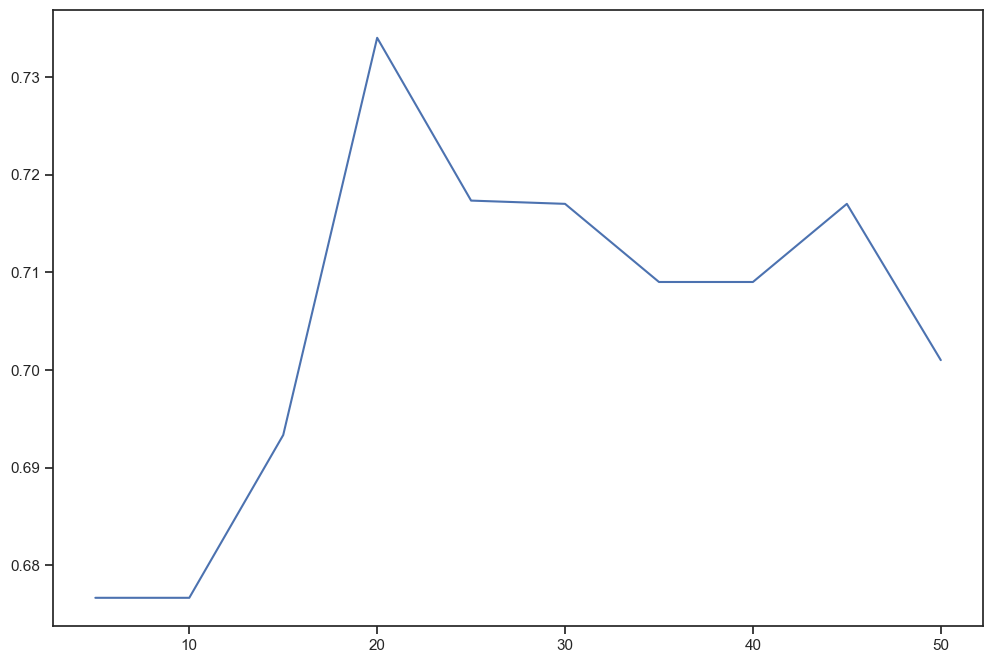

In [441]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])

Accuracy: 1.0000
f1_optimal = 1.0

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


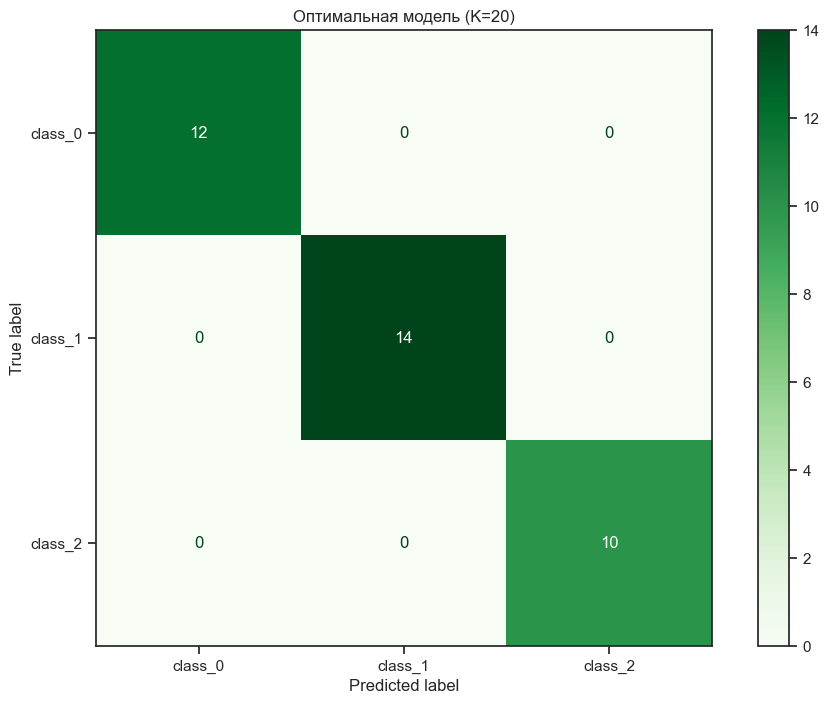

In [458]:
best_knn = grid_search.best_estimator_
y_pred_optimal = best_knn.predict(X_test)
acc_optimal = accuracy_score(y_test, y_pred_optimal)
print(f"Accuracy: {acc_optimal:.4f}")
# 2. F1-score (macro) - для многоклассовой
f1_optimal = f1_score(y_test, y_pred_optimal, average='macro')
print(f'f1_optimal = {f1_optimal}')
# 4. Матрица ошибок
print("\nConfusion Matrix:")
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print(cm_optimal)
# 5. Визуализация матрицы ошибок
ConfusionMatrixDisplay.from_estimator(best_knn, X_test, y_test, 
                                       display_labels=wine.target_names,
                                       cmap=plt.cm.Greens)
plt.title(f'Оптимальная модель (K={clf_gs.best_params_["n_neighbors"]})')
plt.show()

In [443]:
# Randomized Search (случайный поиск)
# Используется в том случае когда полный решетчатый поиск работает слишком долго.
%time
clf_rs = RandomizedSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_rs.fit(wine_X_train, wine_y_train)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 3.1 μs


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'n_neighbors': array([ 5, 10..., 40, 45, 50])}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5

In [444]:
# В данном случае оба способа нашли одинаковое решение
print(clf_rs.best_score_, clf_rs.best_params_)
clf_gs.best_score_, clf_gs.best_params_

0.7340000000000001 {'n_neighbors': np.int64(20)}


(np.float64(0.7340000000000001), {'n_neighbors': np.int64(20)})

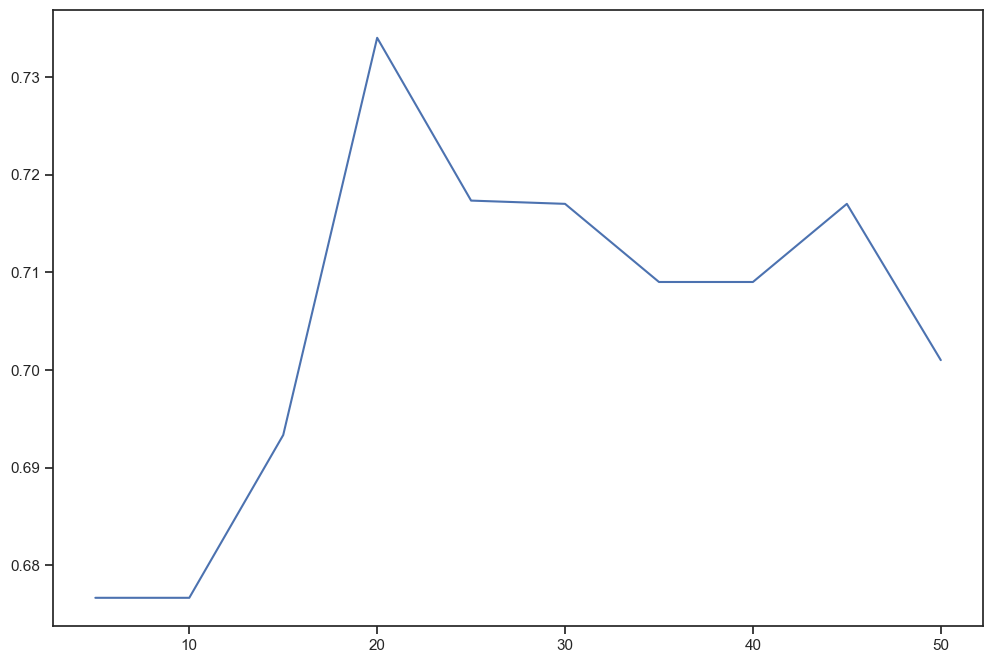

In [445]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_rs.cv_results_['mean_test_score'])

In [446]:
# Построение кривых обучения - learning_curve

In [447]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5), scoring='accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.3,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
 

<module 'matplotlib.pyplot' from '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/pyplot.py'>

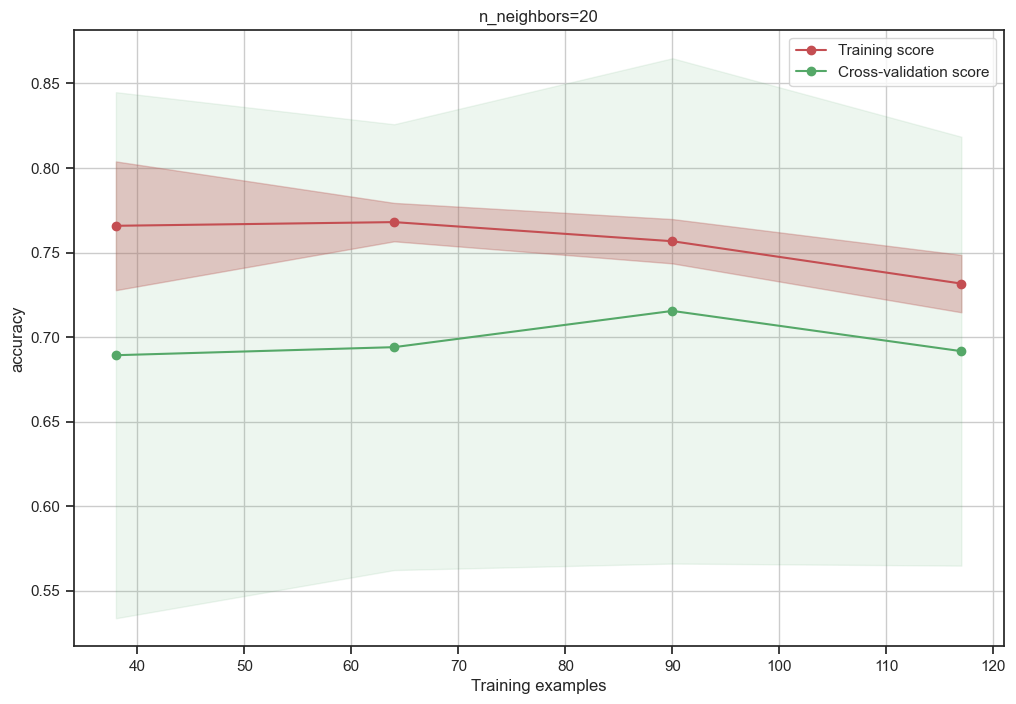

In [448]:
plot_learning_curve(KNeighborsClassifier(n_neighbors=20), 'n_neighbors=20', 
                    wine_X_train, wine_y_train, cv=20)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
 

<module 'matplotlib.pyplot' from '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/pyplot.py'>

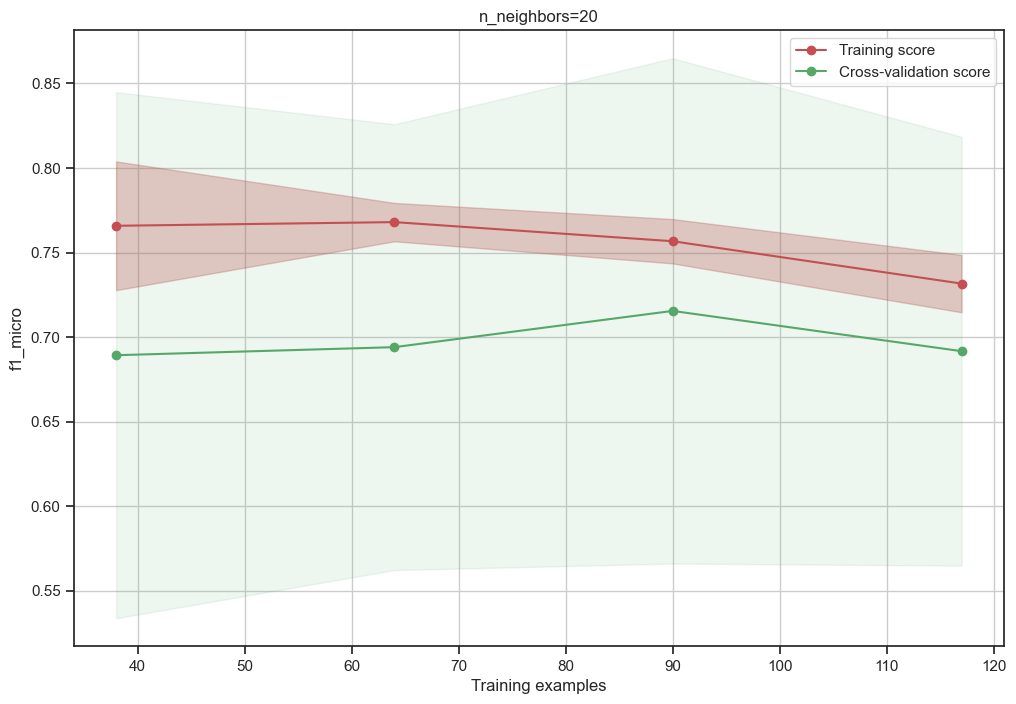

In [449]:
plot_learning_curve(KNeighborsClassifier(n_neighbors=20), 'n_neighbors=20', 
                    wine_X_train, wine_y_train, cv=20, scoring='f1_micro')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
 

<module 'matplotlib.pyplot' from '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/pyplot.py'>

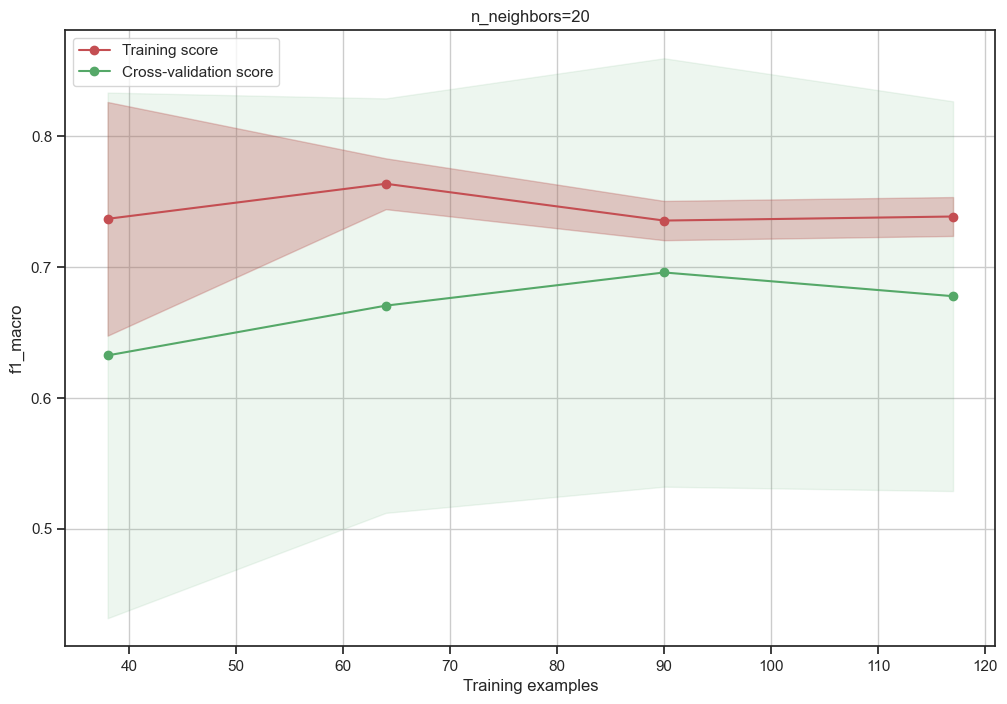

In [450]:
plot_learning_curve(KNeighborsClassifier(n_neighbors=20), 'n_neighbors=20', 
                    wine_X_train, wine_y_train, cv=20, scoring='f1_macro')

In [451]:
def plot_validation_curve(estimator, title, X, y, 
                          param_name, param_range, cv, 
                          scoring='accuracy'):
                                                   
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=1)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel(str(scoring))
    plt.ylim(0.0, 1.1)
    lw = 2
    plt.plot(param_range, train_scores_mean, label="Training score",
                 color="darkorange", lw=lw)
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.4,
                     color="darkorange", lw=lw)
    plt.plot(param_range, test_scores_mean, label="Cross-validation score",
                 color="navy", lw=lw)
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.2,
                     color="navy", lw=lw)
    plt.legend(loc="best")
    return plt

In [452]:
n_range2 = np.array(range(5,125,5))

<module 'matplotlib.pyplot' from '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/pyplot.py'>

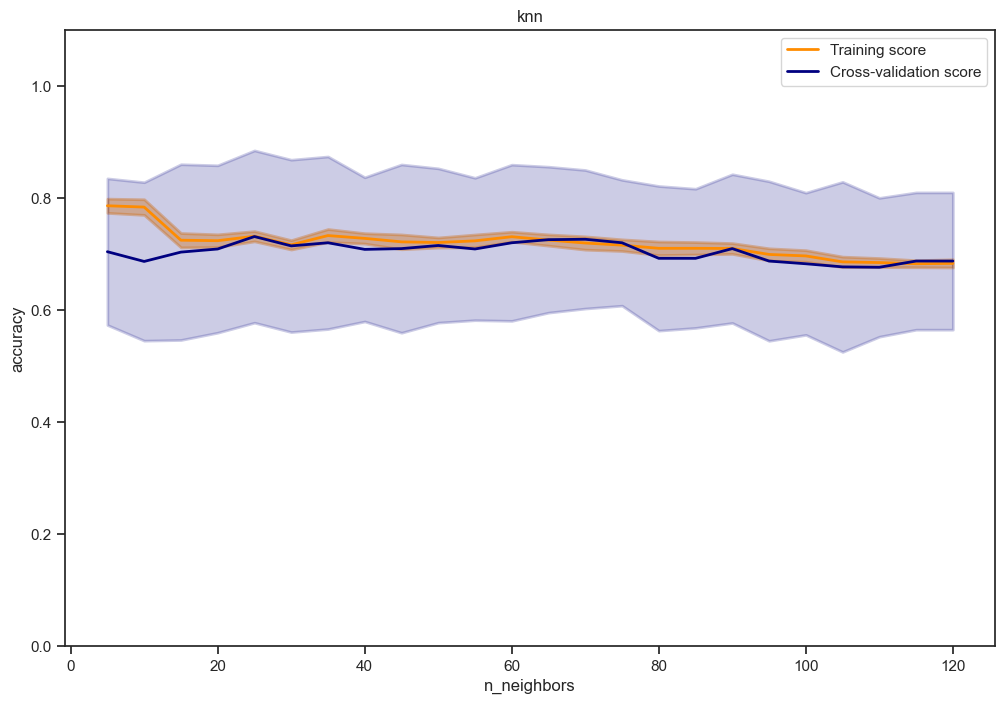

In [453]:
plot_validation_curve(clf_gs.best_estimator_, 'knn', 
                      wine.data, wine.target, 
                      param_name='n_neighbors', param_range=n_range2, 
                      cv=20, scoring="accuracy")